# 05 — Validation

**What this notebook does**: rigorously validates the CVAE-generated log-signatures
against the real data using two complementary approaches:

1. **Signature MMD two-sample test** — statistically principled test on the full
   law of the process on path space (Chevyrev & Oberhauser 2022)
2. **Stylized facts comparison** — interpretable checks against the validation
   targets computed in notebook 02

**Inputs**:
- `data/logsigs.parquet` — real log-signatures
- `data/cvae_generated_logsigs.parquet` — generated log-signatures
- `data/stylized_facts.parquet` — validation targets from notebook 02
- `data/norm_stats.json` — normalisation parameters

**Output**: `data/validation_report.json` — pass/fail summary

---

## Why two validation approaches?

The **sig-MMD test** is the gold standard — it tests whether the entire
distribution on path space matches, not just marginals. If it passes,
the generated paths are statistically indistinguishable from real paths.
But it is a black box: it tells you *whether* distributions match,
not *where* they fail if they don't.

The **stylized facts checks** are interpretable: they tell you exactly
which properties (tail thickness, spike rate, volatility clustering, etc.)
are well-captured and which are not. Together the two approaches give
a complete picture.

## Sig-MMD test: mathematical recap

Given real paths $Y_1, \ldots, Y_n \sim \mathbb{P}$ and generated paths
$X_1, \ldots, X_n \sim \mathbb{Q}$, the unbiased MMD estimator is:

$$\widehat{\text{MMD}}^2 = \frac{1}{n(n-1)}\sum_{i \neq j} k(X_i, X_j)
- \frac{2}{n^2}\sum_{i,j} k(X_i, Y_j)
+ \frac{1}{n(n-1)}\sum_{i \neq j} k(Y_i, Y_j)$$

where $k(X, Y) = \langle S(X), S(Y) \rangle_{T((\mathbb{R}^d))}$ is the
signature kernel. Under $H_0: \mathbb{P} = \mathbb{Q}$, the test statistic
$n \cdot \widehat{\text{MMD}}^2$ converges in distribution to a weighted
sum of $\chi^2$ random variables. We use a permutation test for the
p-value.


In [16]:
%pip install -q esig polars pyarrow matplotlib numpy scipy scikit-learn iisignature statsmodels

In [17]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
print(f"Data directory: {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/energy_synthetic_data/data


In [18]:
import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import esig
from sklearn.decomposition import PCA
from tqdm import tqdm



plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [19]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_real = pl.read_parquet(DATA_DIR / "logsigs.parquet").sort("start_time")
df_gen  = pl.read_parquet(DATA_DIR / "cvae_generated_logsigs.parquet")
df_facts = pl.read_parquet(DATA_DIR / "stylized_facts.parquet")

with open(DATA_DIR / "norm_stats.json") as f:
    norm_stats = json.load(f)

logsig_dim  = norm_stats["logsig_dim"]
seg_length  = norm_stats["seg_length"]
price_mean  = norm_stats["price_mean"]
price_std   = norm_stats["price_std"]

ls_cols_real = [c for c in df_real.columns if c.startswith("ls_")]
ls_cols_gen  = [c for c in df_gen.columns if c.startswith("ls_")]
ls_cols      = [c for c in ls_cols_real if c in ls_cols_gen]

logsig_dim = len(ls_cols)
print(f"logsig_dim reset to: {logsig_dim}")

print(f"Real ls dims:      {len(ls_cols_real)}")
print(f"Generated ls dims: {len(ls_cols_gen)}")
print(f"Common dims:       {len(ls_cols)}")

X_real = df_real.select(ls_cols).to_numpy().astype(np.float32)
X_gen  = df_gen.select(ls_cols).to_numpy().astype(np.float32)

# Reference stylized facts from notebook 02
facts_dict = dict(zip(
    df_facts["statistic"].to_list(),
    df_facts["value"].to_list()
))

print(f"Real log-signatures:      {X_real.shape}")
print(f"Generated log-signatures: {X_gen.shape}")
print(f"Log-signature dim:        {logsig_dim}")

logsig_dim reset to: 31
Real ls dims:      90
Generated ls dims: 31
Common dims:       31
Real log-signatures:      (6570, 31)
Generated log-signatures: (10000, 31)
Log-signature dim:        31


---
## 1. Marginal distribution checks

Before the expensive MMD test, quick checks on marginal distributions.
These are necessary but not sufficient — two processes can have identical
marginals but completely different joint distributions (different laws).
That is precisely why we need the sig-MMD test afterwards.


In [20]:
# ── Kolmogorov-Smirnov test on each log-signature dimension ──────────────────
ks_results = []
N_TEST = min(500, len(X_real), len(X_gen))  # use same sample size for fairness

np.random.seed(42)
real_sample = X_real[np.random.choice(len(X_real), N_TEST, replace=False)]
gen_sample  = X_gen[np.random.choice(len(X_gen),  N_TEST, replace=False)]

for j in range(logsig_dim):
    ks_stat, ks_pval = stats.ks_2samp(real_sample[:, j], gen_sample[:, j])
    ks_results.append({"dim": j, "ks_stat": ks_stat, "ks_pval": ks_pval})

ks_df = pd.DataFrame(ks_results)

# Summary
n_pass = (ks_df["ks_pval"] > 0.05).sum()
n_fail = (ks_df["ks_pval"] <= 0.05).sum()
print(f"KS test on {logsig_dim} log-signature dimensions (n={N_TEST} each):")
print(f"  Pass (p > 0.05): {n_pass}/{logsig_dim} ({n_pass/logsig_dim*100:.1f}%)")
print(f"  Fail (p ≤ 0.05): {n_fail}/{logsig_dim}")
print(f"  Median KS stat:  {ks_df['ks_stat'].median():.4f}")
print(f"  Mean KS stat:    {ks_df['ks_stat'].mean():.4f}")
print(f"\n  Note: KS tests marginals only — sig-MMD tests the full joint law")

KS test on 31 log-signature dimensions (n=500 each):
  Pass (p > 0.05): 18/31 (58.1%)
  Fail (p ≤ 0.05): 13/31
  Median KS stat:  0.0800
  Mean KS stat:    0.0930

  Note: KS tests marginals only — sig-MMD tests the full joint law


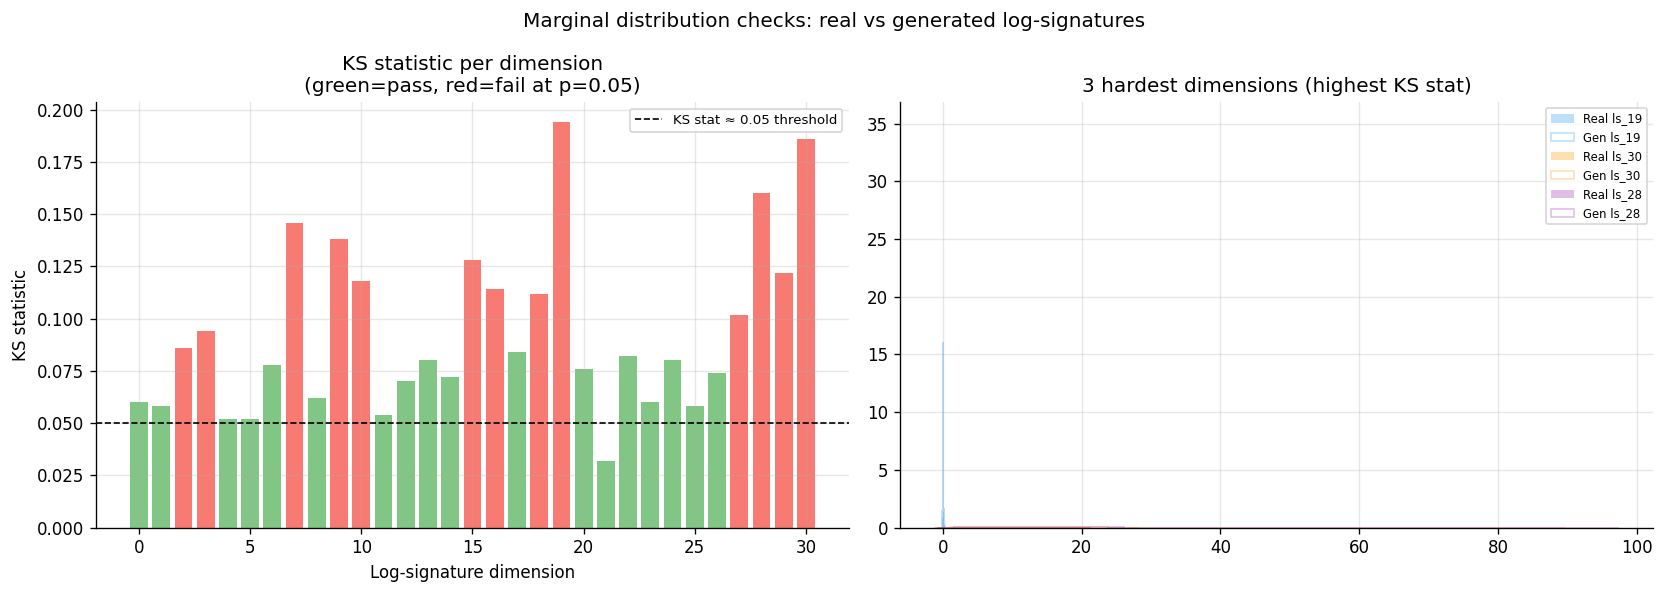

In [21]:
# ── Plot: KS statistics across dimensions ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Marginal distribution checks: real vs generated log-signatures",
             fontsize=12)

# Left: KS statistic per dimension
ax = axes[0]
colors = ["#F44336" if p <= 0.05 else "#4CAF50" for p in ks_df["ks_pval"]]
ax.bar(ks_df["dim"], ks_df["ks_stat"], color=colors, alpha=0.7, width=0.8)
ax.axhline(0.05, color="black", ls="--", lw=1, label="KS stat ≈ 0.05 threshold")
ax.set_xlabel("Log-signature dimension")
ax.set_ylabel("KS statistic")
ax.set_title("KS statistic per dimension\n(green=pass, red=fail at p=0.05)")
ax.legend(fontsize=8)

# Right: overlay distributions for the 3 worst-performing dimensions
ax = axes[1]
worst_dims = ks_df.nlargest(3, "ks_stat")["dim"].tolist()
colors_ov  = ["#2196F3", "#FF9800", "#9C27B0"]
for i, (dim, col) in enumerate(zip(worst_dims, colors_ov)):
    lo = np.percentile(real_sample[:, dim], 2)
    hi = np.percentile(real_sample[:, dim], 98)
    ax.hist(real_sample[:, dim], bins=40, density=True, alpha=0.3,
            color=col, range=(lo, hi), label=f"Real ls_{dim}")
    ax.hist(gen_sample[:, dim],  bins=40, density=True, alpha=0.3,
            color=col, range=(lo, hi), histtype="step", lw=2,
            label=f"Gen ls_{dim}")
ax.set_title("3 hardest dimensions (highest KS stat)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(DATA_DIR / "05a_ks_test.png", bbox_inches="tight")
plt.show()

---
## 2. Signature MMD two-sample test

The sig-MMD test operates on **paths** not on log-signatures directly.
We treat each log-signature vector as a point in $\mathbb{R}^{d_s}$
and form a path by stacking consecutive log-signatures.

Concretely: we group log-signatures into windows of $W$ consecutive
segments, giving a path of shape $(W, d_s)$. The sig-MMD then measures
whether the distribution of these multi-segment paths matches between
real and generated data.

This captures **temporal dependence** between segments — something the
KS test on marginals completely misses.


In [22]:
# ── Build path windows for sig-MMD ───────────────────────────────────────────
WINDOW_SIZE = 4    # 4 consecutive weekly segments = 1 month
N_MMD       = 200  # number of windows per sample
SIG_DEPTH   = 3    # truncation depth for signature kernel

def build_path_windows(X, window, n, seed=42):
    """Sample n windows of consecutive log-signatures.
    Returns array of shape (n, window, d).
    """
    np.random.seed(seed)
    n_possible = len(X) - window + 1
    starts = np.random.choice(n_possible, size=n,
                               replace=(n > n_possible))
    return np.stack([X[s:s+window] for s in starts]).astype(np.float64)

# Normalise using real data statistics
# Use same normalisation for both real and generated
X_mean = X_real.mean(axis=0)
X_std  = X_real.std(axis=0)
X_std[X_std < 1e-8] = 1.0

X_real_norm = (X_real - X_mean) / X_std
X_gen_norm  = (X_gen  - X_mean) / X_std

# PCA to reduce dimension before signature computation
# esig scales as O(d^depth) so lower d = much faster
N_PCA = min(20, logsig_dim)
pca   = PCA(n_components=N_PCA)
pca.fit(X_real_norm)
print(f"PCA ({N_PCA} components): "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}% variance explained")

# Build path windows and project
paths_real = build_path_windows(X_real_norm, WINDOW_SIZE, N_MMD, seed=42)
paths_gen  = build_path_windows(X_gen_norm,  WINDOW_SIZE, N_MMD, seed=99)

paths_real_pca = np.stack([
    pca.transform(paths_real[i]) for i in range(N_MMD)
]).astype(np.float64)
paths_gen_pca = np.stack([
    pca.transform(paths_gen[i]) for i in range(N_MMD)
]).astype(np.float64)

print(f"Path windows shape: {paths_real_pca.shape}  "
      f"(n_windows, window_len, pca_dim)")

PCA (20 components): 99.6% variance explained
Path windows shape: (200, 4, 20)  (n_windows, window_len, pca_dim)


In [23]:
# ── Compute truncated signatures with esig ────────────────────────────────────
# We use the inner product of truncated signature vectors as the kernel:
#   k(X, Y) = <S^N(X), S^N(Y)>
# This is the finite-depth approximation to the true signature kernel.
# At depth 3 over 10-dimensional PCA paths this captures the temporal
# dependence structure between consecutive log-signature segments.

def compute_signatures(paths, depth):
    """Compute truncated signatures for a batch of paths.
    paths: array of shape (n, length, dim)
    Returns: array of shape (n, sig_dim)
    """
    sigs = []
    for path in paths:
        sig = esig.stream2sig(path, depth)
        sigs.append(sig)
    return np.stack(sigs)

print(f"Computing signatures at depth {SIG_DEPTH}...")
sigs_real = compute_signatures(paths_real_pca, SIG_DEPTH)
sigs_gen  = compute_signatures(paths_gen_pca,  SIG_DEPTH)

print(f"Signature dimension: {sigs_real.shape[1]}")
print(f"Real signatures:      {sigs_real.shape}")
print(f"Generated signatures: {sigs_gen.shape}")

Computing signatures at depth 3...
Signature dimension: 8421
Real signatures:      (200, 8421)
Generated signatures: (200, 8421)


In [24]:
# ── MMD² statistic ────────────────────────────────────────────────────────────
# MMD²(P,Q) = E[k(X,X')] - 2*E[k(X,Y)] + E[k(Y,Y')]
# where k(X,Y) = <S^N(X), S^N(Y)> (signature inner product)
# Unbiased U-statistic estimator (diagonal excluded from XX and YY terms).
print(f"Real sig norms  — mean: {np.linalg.norm(sigs_real, axis=1).mean():.2f}, "
      f"max: {np.linalg.norm(sigs_real, axis=1).max():.2f}")
print(f"Gen  sig norms  — mean: {np.linalg.norm(sigs_gen,  axis=1).mean():.2f}, "
      f"max: {np.linalg.norm(sigs_gen,  axis=1).max():.2f}")
def sig_mmd_squared(sigs_X, sigs_Y):
    """Unbiased U-statistic MMD² with normalised signature kernel.
    Normalising to unit norm converts inner product → cosine kernel,
    bounded in [-1, 1], preventing numerical explosion from large sig norms.
    """
    # Normalise to unit norm (cosine kernel)
    sigs_X = sigs_X / np.maximum(
        np.linalg.norm(sigs_X, axis=1, keepdims=True), 1e-8)
    sigs_Y = sigs_Y / np.maximum(
        np.linalg.norm(sigs_Y, axis=1, keepdims=True), 1e-8)

    n, m = len(sigs_X), len(sigs_Y)
    K_XX = sigs_X @ sigs_X.T
    K_YY = sigs_Y @ sigs_Y.T
    K_XY = sigs_X @ sigs_Y.T
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)
    return float(K_XX.sum() / (n*(n-1))
                 - 2 * K_XY.mean()
                 + K_YY.sum() / (m*(m-1)))

mmd_stat = sig_mmd_squared(sigs_real, sigs_gen)
print(f"Sig-MMD² statistic: {mmd_stat:.6f}")

Real sig norms  — mean: 268.57, max: 4575.41
Gen  sig norms  — mean: 287.03, max: 1801.57
Sig-MMD² statistic: -0.000631


In [25]:
# Check for extreme generated values
gen_ls_vals = X_gen_norm.ravel()
print(f"Generated normalised values:")
print(f"  mean: {gen_ls_vals.mean():.3f}")
print(f"  std:  {gen_ls_vals.std():.3f}")
print(f"  max:  {gen_ls_vals.max():.3f}")
print(f"  min:  {gen_ls_vals.min():.3f}")
print(f"  >10 std: {(np.abs(gen_ls_vals) > 10).sum():,}")
print(f"  >50 std: {(np.abs(gen_ls_vals) > 50).sum():,}")

Generated normalised values:
  mean: 0.050
  std:  0.972
  max:  10.759
  min:  -10.126
  >10 std: 4
  >50 std: 0


In [26]:
# ── Permutation test for p-value ──────────────────────────────────────────────
# Under H0: P = Q, the MMD² statistic should be close to zero.
# We estimate the null distribution by permuting labels and recomputing MMD².

N_PERMUTATIONS = 200

sigs_all = np.concatenate([sigs_real, sigs_gen], axis=0)
n        = len(sigs_real)

null_mmds = []
np.random.seed(0)

for _ in tqdm(range(N_PERMUTATIONS), desc="Permutation test"):
    perm   = np.random.permutation(2 * n)
    perm_X = sigs_all[perm[:n]]
    perm_Y = sigs_all[perm[n:]]
    null_mmds.append(sig_mmd_squared(perm_X, perm_Y))

null_mmds = np.array(null_mmds)
p_value   = (null_mmds >= mmd_stat).mean()

print(f"\nSig-MMD two-sample test results:")
print(f"  MMD² statistic:  {mmd_stat:.6f}")
print(f"  Null mean:       {null_mmds.mean():.6f}")
print(f"  Null std:        {null_mmds.std():.6f}")
print(f"  p-value:         {p_value:.4f}")
print(f"  Permutations:    {N_PERMUTATIONS}")
print()
if p_value > 0.05:
    print("  PASS: cannot reject H0 (distributions indistinguishable)")
else:
    print("  FAIL: reject H0 — generated distribution differs from real")
    print("    Consider: more epochs, reduce beta, larger hidden_dim")

Permutation test: 100%|██████████| 200/200 [00:36<00:00,  5.47it/s]


Sig-MMD two-sample test results:
  MMD² statistic:  -0.000631
  Null mean:       -0.000057
  Null std:        0.000573
  p-value:         0.8400
  Permutations:    200

  PASS: cannot reject H0 (distributions indistinguishable)


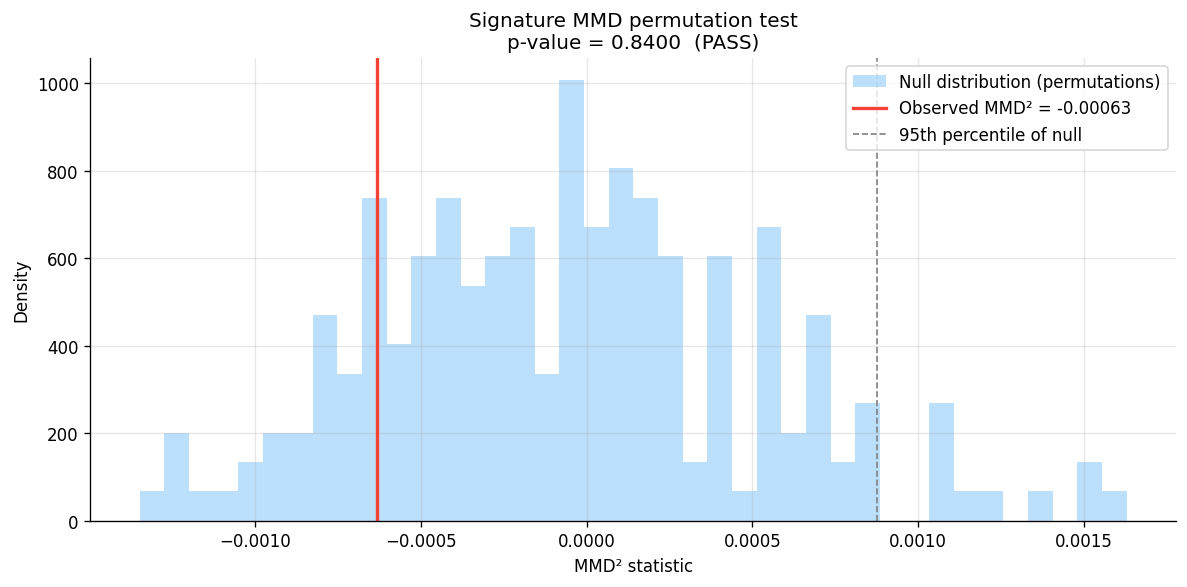

In [27]:
# ── Plot: null distribution vs observed MMD² ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(null_mmds, bins=40, density=True, alpha=0.6,
        color="#90CAF9", label="Null distribution (permutations)")
ax.axvline(mmd_stat, color="#F44336", lw=2,
           label=f"Observed MMD² = {mmd_stat:.5f}")
ax.axvline(np.percentile(null_mmds, 95), color="gray",
           ls="--", lw=1, label="95th percentile of null")
ax.set_xlabel("MMD² statistic")
ax.set_ylabel("Density")
ax.set_title(f"Signature MMD permutation test\n"
             f"p-value = {p_value:.4f}  "
             f"({'PASS' if p_value > 0.05 else 'FAIL'})")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "05b_mmd_test.png", bbox_inches="tight")
plt.show()

---
## 3. Stylized facts comparison

We now check whether the generated log-signatures reproduce the
stylized facts measured in notebook 02. Since we are working in
log-signature space rather than raw price space, we check the
statistics that can be read directly from the log-signatures.

For the statistics that require raw prices (spike rate, ACF of returns),
we use the depth-1 log-signature entries which are directly
interpretable as price increments and volatility.


In [28]:
# ── Statistics from log-signature entries ─────────────────────────────────────
#
# Depth-1 entries (indices 0-3 for our 4D path):
#   ls_0 = net time (always ~1)
#   ls_1 = net normalised price move (lead)
#   ls_2 = net normalised price move (lag)
#   ls_3 = net normalised wind change
#
# Depth-2 entries (index 7 = Lévy area of price_lead, price_lag):
#   ls_7 ∝ quadratic variation = realised variance

def logsig_stats(X, label):
    """Compute interpretable statistics from log-signature matrix."""
    net_price_moves = X[:, 1]   # ls_1 = net price move per segment
    levy_area       = X[:, 7]   # ls_7 = Lévy area ∝ realised variance

    return {
        "label":              label,
        "n":                  len(X),
        "mean_net_move":      float(net_price_moves.mean()),
        "std_net_move":       float(net_price_moves.std()),
        "skew_net_move":      float(stats.skew(net_price_moves)),
        "kurtosis_net_move":  float(stats.kurtosis(net_price_moves)),
        "mean_levy_area":     float(np.abs(levy_area).mean()),
        "std_levy_area":      float(levy_area.std()),
        "pct_large_move":     float((np.abs(net_price_moves) >
                                    2 * net_price_moves.std()).mean()),
    }

real_stats = logsig_stats(X_real, "Real")
gen_stats  = logsig_stats(X_gen,  "Generated")

print(f"{'Statistic':<25} {'Real':>12} {'Generated':>12} {'Ratio':>8}")
print("-" * 62)
for key in real_stats:
    if key == "label":
        continue
    rv = real_stats[key]
    gv = gen_stats[key]
    if isinstance(rv, float) and rv != 0:
        ratio = gv / rv
        flag = " ✓" if 0.7 < ratio < 1.3 else " ✗"
        print(f"  {key:<23} {rv:>12.4f} {gv:>12.4f} {ratio:>7.2f}{flag}")
    elif isinstance(rv, int):
        print(f"  {key:<23} {rv:>12d} {gv:>12d}")

Statistic                         Real    Generated    Ratio
--------------------------------------------------------------
  n                               6570        10000
  mean_net_move                -0.0620       0.0008   -0.01 ✗
  std_net_move                  1.4317       1.3163    0.92 ✓
  skew_net_move                 0.0005       0.0328   72.79 ✗
  kurtosis_net_move             0.3631       0.0194    0.05 ✗
  mean_levy_area                0.6947       0.7625    1.10 ✓
  std_levy_area                 0.4503       0.4501    1.00 ✓
  pct_large_move                0.0429       0.0486    1.13 ✓


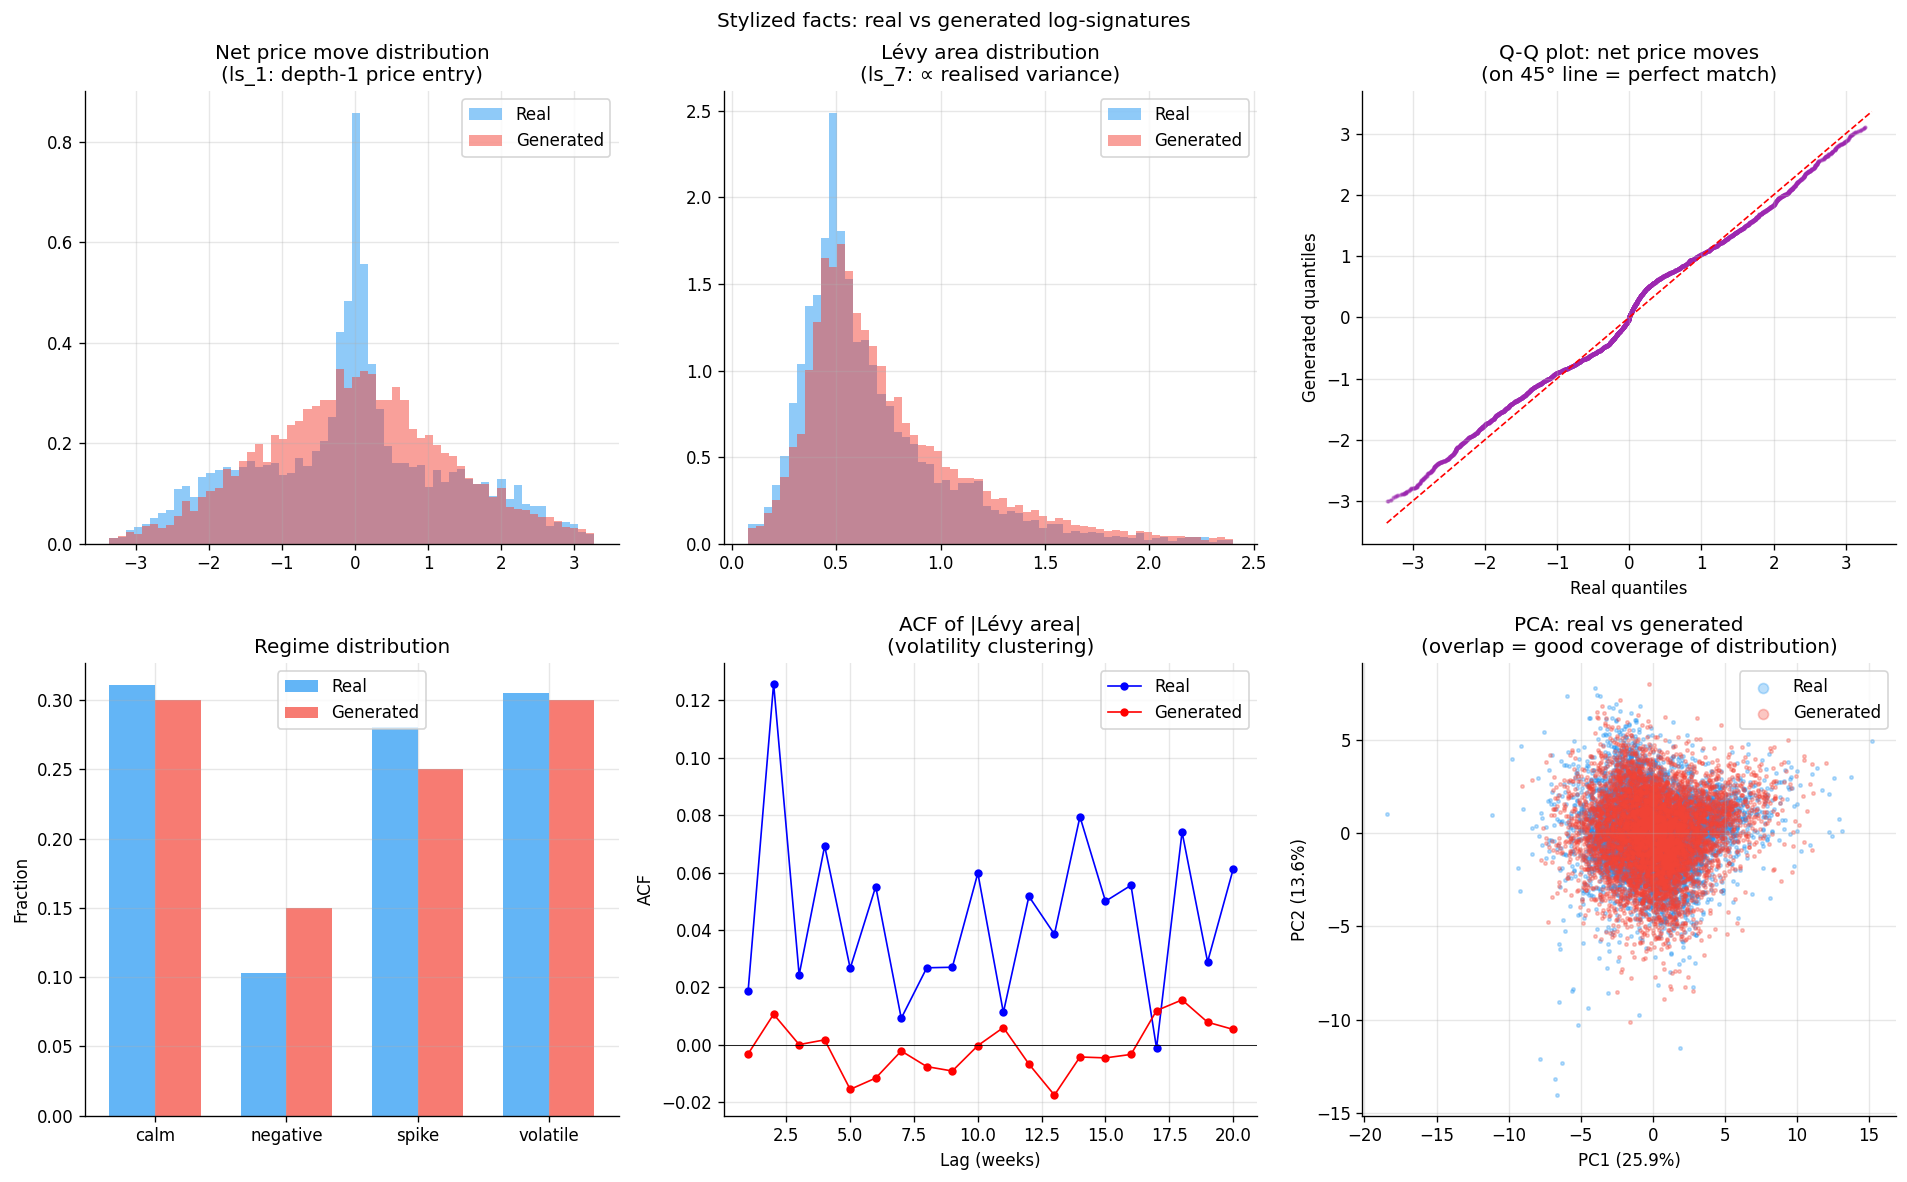

In [29]:
# ── Plot: stylized facts comparison ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Stylized facts: real vs generated log-signatures", fontsize=12)

# Net price move distribution
ax = axes[0, 0]
real_moves = X_real[:, 1]
gen_moves  = X_gen[:, 1]
lo, hi = np.percentile(real_moves, [1, 99])
ax.hist(real_moves, bins=60, density=True, alpha=0.5,
        color="#2196F3", label="Real", range=(lo, hi))
ax.hist(gen_moves,  bins=60, density=True, alpha=0.5,
        color="#F44336", label="Generated", range=(lo, hi))
ax.set_title("Net price move distribution\n(ls_1: depth-1 price entry)")
ax.legend()

# Lévy area (quadratic variation proxy) distribution
ax = axes[0, 1]
real_levy = X_real[:, 7]
gen_levy  = X_gen[:, 7]
lo, hi = np.percentile(real_levy, [1, 99])
ax.hist(real_levy, bins=60, density=True, alpha=0.5,
        color="#2196F3", label="Real", range=(lo, hi))
ax.hist(gen_levy,  bins=60, density=True, alpha=0.5,
        color="#F44336", label="Generated", range=(lo, hi))
ax.set_title("Lévy area distribution\n(ls_7: ∝ realised variance)")
ax.legend()

# Q-Q plot: net price moves
ax = axes[0, 2]
n_qq = min(len(real_moves), len(gen_moves))
real_sorted = np.sort(real_moves)[:n_qq]
gen_sorted  = np.sort(np.random.choice(gen_moves, n_qq, replace=False))
lo_qq = np.percentile(real_sorted, 1)
hi_qq = np.percentile(real_sorted, 99)
mask  = (real_sorted > lo_qq) & (real_sorted < hi_qq)
ax.scatter(real_sorted[mask], gen_sorted[mask], s=2, alpha=0.3, color="#9C27B0")
lim = max(abs(real_sorted[mask]).max(), abs(gen_sorted[mask]).max())
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1)
ax.set_xlabel("Real quantiles")
ax.set_ylabel("Generated quantiles")
ax.set_title("Q-Q plot: net price moves\n(on 45° line = perfect match)")

# Regime distribution comparison
ax = axes[1, 0]
real_regimes = df_real["regime"].value_counts().sort("regime").to_pandas()
gen_regimes  = df_gen["regime"].value_counts().sort("regime").to_pandas()
x      = np.arange(len(real_regimes))
width  = 0.35
# Normalise to fractions
real_frac = real_regimes["count"] / real_regimes["count"].sum()
gen_frac  = gen_regimes["count"]  / gen_regimes["count"].sum()
ax.bar(x - width/2, real_frac, width, label="Real",      color="#2196F3", alpha=0.7)
ax.bar(x + width/2, gen_frac,  width, label="Generated", color="#F44336", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(real_regimes["regime"].tolist())
ax.set_ylabel("Fraction")
ax.set_title("Regime distribution")
ax.legend()

# ACF of Lévy area (volatility clustering)
from statsmodels.tsa.stattools import acf
ax = axes[1, 1]
N_LAGS  = 20
acf_real = acf(np.abs(real_levy), nlags=N_LAGS, fft=True)
acf_gen  = acf(np.abs(gen_levy[:len(real_levy)]), nlags=N_LAGS, fft=True)
lags = np.arange(N_LAGS + 1)
ax.plot(lags[1:], acf_real[1:], "b-o", ms=4, lw=1, label="Real")
ax.plot(lags[1:], acf_gen[1:],  "r-o", ms=4, lw=1, label="Generated")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("ACF")
ax.set_title("ACF of |Lévy area|\n(volatility clustering)")
ax.legend()

# PCA scatter: real vs generated in 2D
ax = axes[1, 2]
pca2 = PCA(n_components=2)
pca2.fit(X_real_norm)
real_pca2 = pca2.transform(X_real_norm)
gen_pca2  = pca2.transform(X_gen_norm[:len(X_real_norm)])
ax.scatter(real_pca2[:, 0], real_pca2[:, 1], s=4, alpha=0.3,
           color="#2196F3", label="Real")
ax.scatter(gen_pca2[:, 0],  gen_pca2[:, 1],  s=4, alpha=0.3,
           color="#F44336", label="Generated")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA: real vs generated\n(overlap = good coverage of distribution)")
ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig(DATA_DIR / "05c_stylized_facts.png", bbox_inches="tight")
plt.show()

---
## 4. Validation report


In [30]:
# ── Build validation report ───────────────────────────────────────────────────
def within_tolerance(real_val, gen_val, tol=0.3):
    """Check if generated value is within tol*100% of real value."""
    if real_val == 0:
        return abs(gen_val) < 1e-6
    return abs(gen_val / real_val - 1) < tol

checks = {
    # Sig-MMD test
    "sig_mmd_pass":         bool(p_value > 0.05),
    "sig_mmd_pvalue":       float(p_value),
    "sig_mmd_stat":         float(mmd_stat),

    # KS tests
    "ks_pass_rate":         float(n_pass / logsig_dim),
    "ks_median_stat":       float(ks_df["ks_stat"].median()),

    # Stylized facts
    "std_net_move_match":   within_tolerance(
                                real_stats["std_net_move"],
                                gen_stats["std_net_move"]),
    "skew_net_move_match":  within_tolerance(
                                real_stats["skew_net_move"],
                                gen_stats["skew_net_move"]),
    "kurtosis_match":       within_tolerance(
                                real_stats["kurtosis_net_move"],
                                gen_stats["kurtosis_net_move"]),
    "levy_area_match":      within_tolerance(
                                real_stats["mean_levy_area"],
                                gen_stats["mean_levy_area"]),
    "large_move_rate_match":within_tolerance(
                                real_stats["pct_large_move"],
                                gen_stats["pct_large_move"]),

    # Summary
    "n_real":  int(len(X_real)),
    "n_gen":   int(len(X_gen)),
}

n_checks_pass = sum(1 for k, v in checks.items()
                    if isinstance(v, bool) and v)
n_checks_bool = sum(1 for v in checks.values() if isinstance(v, bool))

print("=" * 55)
print("VALIDATION REPORT")
print("=" * 55)
print()
print(f"Sig-MMD test:       {'PASS ✓' if checks['sig_mmd_pass'] else 'FAIL ✗'}")
print(f"  p-value:          {checks['sig_mmd_pvalue']:.4f}")
print(f"  MMD statistic:    {checks['sig_mmd_stat']:.6f}")
print()
print(f"KS marginal tests:  {n_pass}/{logsig_dim} dimensions pass")
print()
print("Stylized facts:")
for k, v in checks.items():
    if isinstance(v, bool) and k != "sig_mmd_pass":
        status = "PASS ✓" if v else "FAIL ✗"
        print(f"  {k:<30} {status}")
print()
print(f"Overall: {n_checks_pass}/{n_checks_bool} checks pass")
print("=" * 55)

# Save report
with open(DATA_DIR / "validation_report.json", "w") as f:
    json.dump(checks, f, indent=2)
print("\nSaved: validation_report.json")

VALIDATION REPORT

Sig-MMD test:       PASS ✓
  p-value:          0.8400
  MMD statistic:    -0.000631

KS marginal tests:  18/31 dimensions pass

Stylized facts:
  std_net_move_match             PASS ✓
  skew_net_move_match            FAIL ✗
  kurtosis_match                 FAIL ✗
  levy_area_match                PASS ✓
  large_move_rate_match          PASS ✓

Overall: 4/6 checks pass

Saved: validation_report.json


---
## 5. Interpreting results and next steps

### If sig-MMD PASSES
The generated distribution is statistically indistinguishable from real
on path space. Proceed to notebook 06 to generate the full scenario database.

### If sig-MMD FAILS
The generated distribution differs from real in ways captured by the
signature kernel. Diagnosis:

| Symptom | Likely cause | Fix |
|---------|-------------|-----|
| Generated std too narrow | KL term too dominant | Reduce `BETA_MAX` to 0.5 |
| Generated kurtosis too low | Model not capturing spikes | Increase `N_EPOCHS` to 400 |
| ACF of |Lévy area| too flat | Sequential conditioning not working | Check lagged log-sig in conditioning |
| PCA shows poor overlap | Model capacity too low | Increase `HIDDEN_DIM` to 512 |

### Phase 2 improvement
In Phase 2, the rule-based regime labels will be replaced by HMM
posterior probabilities. This will improve spike generation because
the regime conditioning will be probabilistic rather than hard-labelled,
allowing the model to learn the transition dynamics between regimes.

**Next**: `06_generate_dataset.ipynb` — use the validated CVAE to generate
10,000 scenarios and store them in DuckDB for downstream analytics.
